# California Housing Price Prediction

In this project, I aim to build and evaluate several **Machine Learning regression models** to predict house prices using the California Housing dataset.

## Project Workflow

1. **Exploratory Data Analysis (EDA)**

   * Explore the dataset structure
   * Analyze feature distributions
   * Examine relationships between features and house prices

2. **Data Cleaning**

   * Handle missing values
   * Check for duplicate and invalid data

3. **Feature Engineering**

   * Create meaningful new features
   * Remove unnecessary features

4. **Data Preprocessing**

   * Handle missing values
   * Encode categorical features
   * Scale numerical features when required

5. **Train / Test Split**

   * Split the dataset into training and testing sets

6. **Model Training**

   * Linear Regression
   * Ridge Regression
   * Lasso Regression
   * Decision Tree Regressor
   * Random Forest Regressor
   * Gradient Boosting Regressor
   * HistGradientBoosting Regressor

7. **Model Evaluation**

   * R² Score
   * MAE
   * MSE
   * RMSE
   * Cross-Validation

8. **Hyperparameter Tuning**

   * Use `GridSearchCV` to find the best hyperparameters

9. **Model Comparison**

   * Compare the performance of different models
   * Select the best-performing model

10. **Error Analysis**

    * Analyze residuals
    * Compare actual and predicted values
    * Investigate model errors

11. **Model Saving**

    * Save the final model for future use


# Project Overview

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load Dataset

In [3]:
df = pd.read_csv('D:\\project\\Github_repository\\California_House\\california-housing-ml\\src\\Housing.csv')
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


# 2. Exploratory Data Analysis (EDA)

In [4]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [6]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [7]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

In [8]:
df[df.duplicated()]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity


In [9]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [10]:
df['rooms_per_household'] = df['total_rooms'] / df['households']

In [11]:
df['bedroom_ratio_percenteage'] = df['total_bedrooms'] / df['total_rooms'] * 100
df['bedroom_ratio_percenteage']

0        14.659091
1        15.579659
2        12.951602
3        18.445840
4        17.209588
           ...    
20635    22.462462
20636    21.520803
20637    21.517303
20638    21.989247
20639    22.118492
Name: bedroom_ratio_percenteage, Length: 20640, dtype: float64

In [12]:
df['population_per_household'] = df['population'] / df['households']

In [13]:
df['rooms_per_person'] = df['total_bedrooms'] / df['population']

In [14]:
df['housing_median_age'].sort_values().unique()

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
       14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26.,
       27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38., 39.,
       40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50., 51., 52.])

In [15]:
bins = [0, 10, 20, 30, 40, np.inf]
labels=['new', 'young', 'middle', 'old', 'very_old']

df['age_house_category'] = pd.cut(df['housing_median_age'], bins=bins, labels=labels)
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedroom_ratio_percenteage,population_per_household,rooms_per_person,age_house_category
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,14.659091,2.555556,0.400621,very_old
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,15.579659,2.109842,0.460641,middle
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,12.951602,2.802260,0.383065,very_old
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,18.445840,2.547945,0.421147,very_old
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,17.209588,2.181467,0.495575,very_old
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,5.045455,22.462462,2.560606,0.442604,middle
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,6.114035,21.520803,3.122807,0.421348,young
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,5.205543,21.517303,2.325635,0.481629,young
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,5.329513,21.989247,2.123209,0.551957,young


In [16]:
df.groupby('ocean_proximity')['median_house_value'].mean()

ocean_proximity
<1H OCEAN     240084.285464
INLAND        124805.392001
ISLAND        380440.000000
NEAR BAY      259212.311790
NEAR OCEAN    249433.977427
Name: median_house_value, dtype: float64

In [17]:
df['near_ocean'] = df['ocean_proximity'].isin(['<1H OCEAN', 'NEAR BAY', 'NEAR OCEAN']).astype('category')
df['near_ocean'] = df['near_ocean'].cat.codes
df['near_ocean']

0        1
1        1
2        1
3        1
4        1
        ..
20635    0
20636    0
20637    0
20638    0
20639    0
Name: near_ocean, Length: 20640, dtype: int8

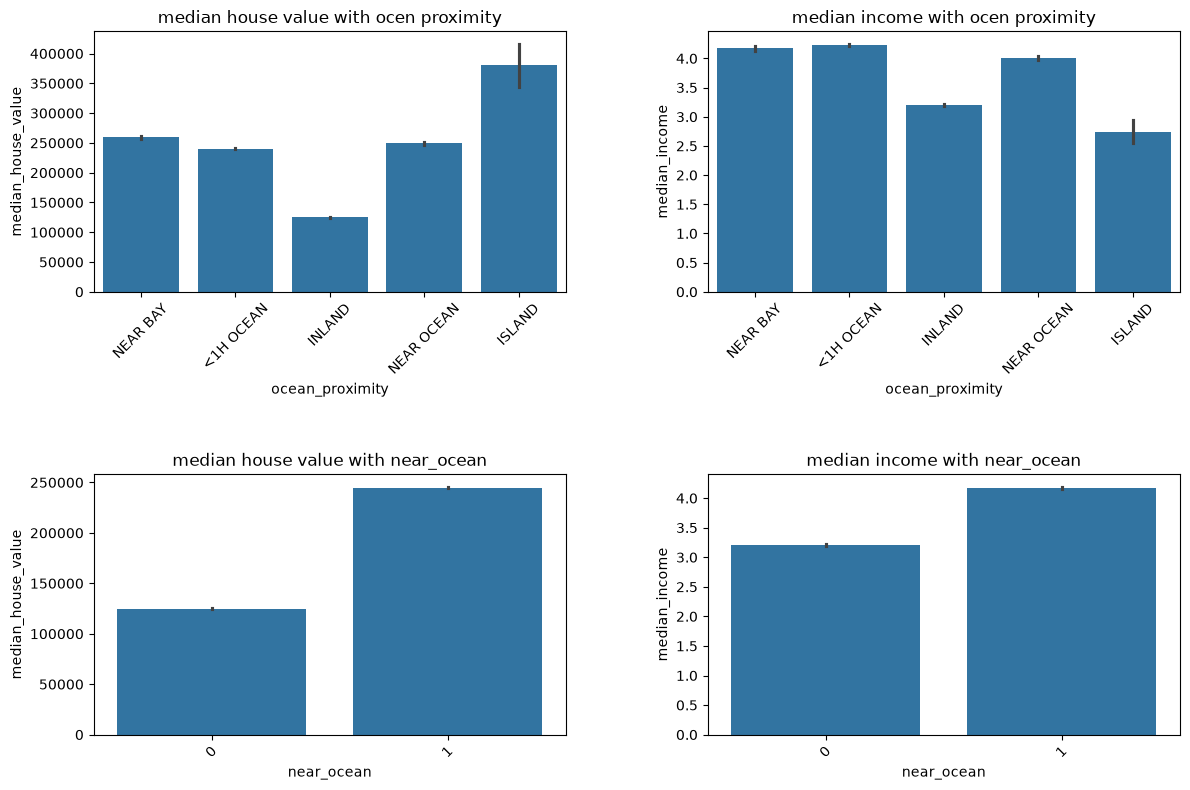

In [18]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

sns.barplot(
    data=df,
    x='ocean_proximity',
    y='median_house_value',
    errorbar='se',
    ax=axs[0, 0]
)
axs[0, 0].tick_params(axis='x', rotation=45)
axs[0, 0].set_title('median house value with ocen proximity')


sns.barplot(
    data=df,
    x='ocean_proximity',
    y='median_income',
    errorbar='se',
    ax=axs[0, 1]
)
axs[0, 1].tick_params(axis='x', rotation=45)
axs[0, 1].set_title('median income with ocen proximity')

sns.barplot(
    data=df,
    x='near_ocean',
    y='median_house_value',
    errorbar='se',
    ax=axs[1, 0]
)
axs[1, 0].tick_params(axis='x', rotation=45)
axs[1, 0].set_title('median house value with near_ocean')


sns.barplot(
    data=df,
    x='near_ocean',
    y='median_income',
    errorbar='se',
    ax=axs[1, 1]
)
axs[1, 1].tick_params(axis='x', rotation=45)
axs[1, 1].set_title('median income with near_ocean')



plt.tight_layout()
plt.subplots_adjust(hspace=0.7, wspace=0.3)

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   longitude                  20640 non-null  float64 
 1   latitude                   20640 non-null  float64 
 2   housing_median_age         20640 non-null  float64 
 3   total_rooms                20640 non-null  float64 
 4   total_bedrooms             20433 non-null  float64 
 5   population                 20640 non-null  float64 
 6   households                 20640 non-null  float64 
 7   median_income              20640 non-null  float64 
 8   median_house_value         20640 non-null  float64 
 9   ocean_proximity            20640 non-null  str     
 10  rooms_per_household        20640 non-null  float64 
 11  bedroom_ratio_percenteage  20433 non-null  float64 
 12  population_per_household   20640 non-null  float64 
 13  rooms_per_person           20433 non-null 

<Axes: xlabel='median_house_value', ylabel='Count'>

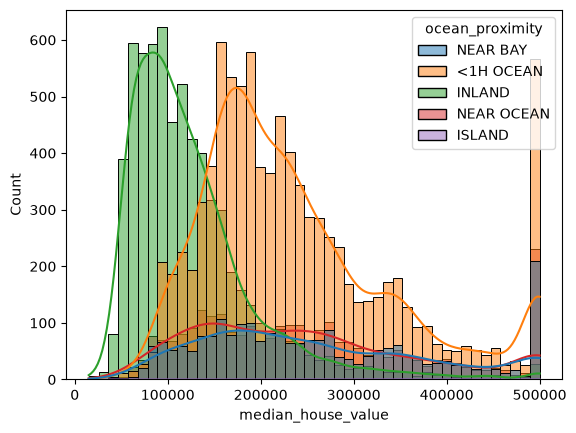

In [20]:
sns.histplot(df, x='median_house_value', kde=True, hue='ocean_proximity')

In [21]:
df = pd.get_dummies(df, columns=['ocean_proximity'], dtype=int)
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedroom_ratio_percenteage,population_per_household,rooms_per_person,age_house_category,near_ocean,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,6.984127,14.659091,2.555556,0.400621,very_old,1,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,6.238137,15.579659,2.109842,0.460641,middle,1,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,8.288136,12.951602,2.802260,0.383065,very_old,1,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,5.817352,18.445840,2.547945,0.421147,very_old,1,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,6.281853,17.209588,2.181467,0.495575,very_old,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,5.045455,22.462462,2.560606,0.442604,middle,0,0,1,0,0,0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,6.114035,21.520803,3.122807,0.421348,young,0,0,1,0,0,0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,5.205543,21.517303,2.325635,0.481629,young,0,0,1,0,0,0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,5.329513,21.989247,2.123209,0.551957,young,0,0,1,0,0,0


In [22]:
df['age_house_category_code'] = df['age_house_category'].cat.codes

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   longitude                   20640 non-null  float64 
 1   latitude                    20640 non-null  float64 
 2   housing_median_age          20640 non-null  float64 
 3   total_rooms                 20640 non-null  float64 
 4   total_bedrooms              20433 non-null  float64 
 5   population                  20640 non-null  float64 
 6   households                  20640 non-null  float64 
 7   median_income               20640 non-null  float64 
 8   median_house_value          20640 non-null  float64 
 9   rooms_per_household         20640 non-null  float64 
 10  bedroom_ratio_percenteage   20433 non-null  float64 
 11  population_per_household    20640 non-null  float64 
 12  rooms_per_person            20433 non-null  float64 
 13  age_house_category         

In [24]:
abs(df.drop(columns='age_house_category').corr()['median_house_value']).sort_values(ascending=False)

median_house_value            1.000000
median_income                 0.688075
ocean_proximity_INLAND        0.484859
near_ocean                    0.483978
ocean_proximity_<1H OCEAN     0.256617
bedroom_ratio_percenteage     0.255880
ocean_proximity_NEAR BAY      0.160284
rooms_per_household           0.151948
latitude                      0.144160
ocean_proximity_NEAR OCEAN    0.141862
total_rooms                   0.134153
housing_median_age            0.105623
age_house_category_code       0.091337
rooms_per_person              0.069896
households                    0.065843
total_bedrooms                0.049686
longitude                     0.045967
population                    0.024650
population_per_household      0.023737
ocean_proximity_ISLAND        0.023416
Name: median_house_value, dtype: float64

In [25]:
df['location_zone'] = (
    df['latitude'].round(1).astype(str)
    + '_'
    + df['longitude'].round(1).astype(str)
)
df['location_zone'].value_counts().shape

(1563,)

In [26]:
df['location_zone'].nunique()

1563

In [27]:
print(df['longitude'].mean())
print(df['latitude'].mean())

-119.56970445736432
35.63186143410852


In [28]:
df['longitude'] - df['longitude'].mean()

0       -2.660296
1       -2.650296
2       -2.670296
3       -2.680296
4       -2.680296
           ...   
20635   -1.520296
20636   -1.640296
20637   -1.650296
20638   -1.750296
20639   -1.670296
Name: longitude, Length: 20640, dtype: float64

In [29]:
df['distance_from_center'] = (
    (df['longitude'] - df['longitude'].mean())**2 +
    (df['latitude'] - df['latitude'].mean())**2
)**0.5
df['distance_from_center'].describe()


count    20640.000000
mean         2.745208
std          1.019755
min          0.120879
25%          2.092457
50%          2.604947
75%          3.472759
max          7.804914
Name: distance_from_center, dtype: float64

In [30]:
abs(df.drop(columns=['age_house_category', 'location_zone']).corr()['median_house_value']).sort_values(ascending=False)

median_house_value            1.000000
median_income                 0.688075
ocean_proximity_INLAND        0.484859
near_ocean                    0.483978
ocean_proximity_<1H OCEAN     0.256617
bedroom_ratio_percenteage     0.255880
ocean_proximity_NEAR BAY      0.160284
rooms_per_household           0.151948
latitude                      0.144160
ocean_proximity_NEAR OCEAN    0.141862
total_rooms                   0.134153
housing_median_age            0.105623
age_house_category_code       0.091337
rooms_per_person              0.069896
distance_from_center          0.069569
households                    0.065843
total_bedrooms                0.049686
longitude                     0.045967
population                    0.024650
population_per_household      0.023737
ocean_proximity_ISLAND        0.023416
Name: median_house_value, dtype: float64

In [31]:
df.isna().sum()

longitude                       0
latitude                        0
housing_median_age              0
total_rooms                     0
total_bedrooms                207
population                      0
households                      0
median_income                   0
median_house_value              0
rooms_per_household             0
bedroom_ratio_percenteage     207
population_per_household        0
rooms_per_person              207
age_house_category              0
near_ocean                      0
ocean_proximity_<1H OCEAN       0
ocean_proximity_INLAND          0
ocean_proximity_ISLAND          0
ocean_proximity_NEAR BAY        0
ocean_proximity_NEAR OCEAN      0
age_house_category_code         0
location_zone                   0
distance_from_center            0
dtype: int64

<Axes: xlabel='median_house_value', ylabel='Count'>

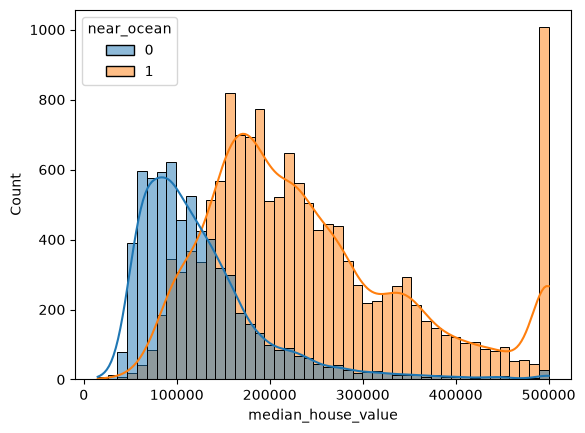

In [32]:
sns.histplot(df, x='median_house_value', kde=True, hue='near_ocean')

In [33]:
df['near_ocean']

0        1
1        1
2        1
3        1
4        1
        ..
20635    0
20636    0
20637    0
20638    0
20639    0
Name: near_ocean, Length: 20640, dtype: int8

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   longitude                   20640 non-null  float64 
 1   latitude                    20640 non-null  float64 
 2   housing_median_age          20640 non-null  float64 
 3   total_rooms                 20640 non-null  float64 
 4   total_bedrooms              20433 non-null  float64 
 5   population                  20640 non-null  float64 
 6   households                  20640 non-null  float64 
 7   median_income               20640 non-null  float64 
 8   median_house_value          20640 non-null  float64 
 9   rooms_per_household         20640 non-null  float64 
 10  bedroom_ratio_percenteage   20433 non-null  float64 
 11  population_per_household    20640 non-null  float64 
 12  rooms_per_person            20433 non-null  float64 
 13  age_house_category         

In [35]:
abs(df.drop(columns=['age_house_category', 'location_zone']).corr()['median_house_value']).sort_values(ascending=False) > 0.05

median_house_value             True
median_income                  True
ocean_proximity_INLAND         True
near_ocean                     True
ocean_proximity_<1H OCEAN      True
bedroom_ratio_percenteage      True
ocean_proximity_NEAR BAY       True
rooms_per_household            True
latitude                       True
ocean_proximity_NEAR OCEAN     True
total_rooms                    True
housing_median_age             True
age_house_category_code        True
rooms_per_person               True
distance_from_center           True
households                     True
total_bedrooms                False
longitude                     False
population                    False
population_per_household      False
ocean_proximity_ISLAND        False
Name: median_house_value, dtype: bool

In [36]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,...,age_house_category,near_ocean,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,age_house_category_code,location_zone,distance_from_center
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,6.984127,...,very_old,1,0,0,0,1,0,4,37.9_-122.2,3.483001
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,6.238137,...,middle,1,0,0,0,1,0,2,37.9_-122.2,3.462466
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,8.288136,...,very_old,1,0,0,0,1,0,4,37.8_-122.2,3.471400
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,5.817352,...,very_old,1,0,0,0,1,0,4,37.8_-122.2,3.479098
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,6.281853,...,very_old,1,0,0,0,1,0,4,37.8_-122.2,3.479098


<Axes: xlabel='median_income', ylabel='median_house_value'>

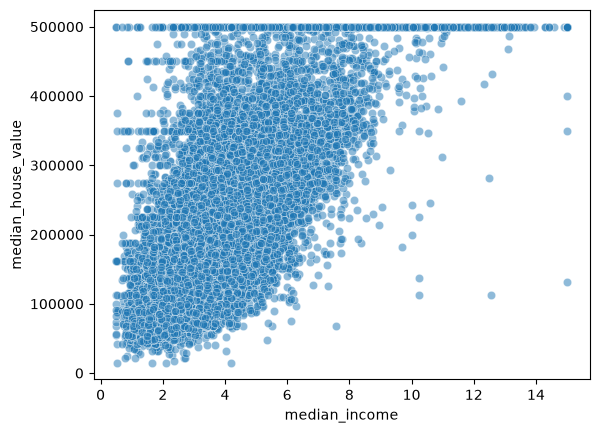

In [37]:
sns.scatterplot(df, x='median_income',y='median_house_value', alpha=0.5)

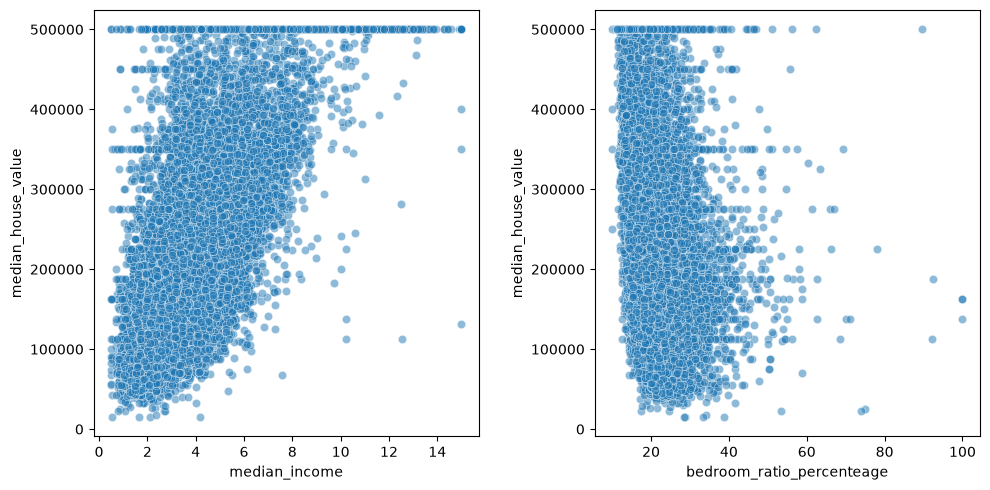

In [38]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

sns.scatterplot(df, x='median_income',y='median_house_value', alpha=0.5, ax=axs[0])

sns.scatterplot(df, x='bedroom_ratio_percenteage',y='median_house_value', alpha=0.5, ax=axs[1])




plt.tight_layout()
plt.subplots_adjust(hspace=0.5, wspace=0.3)

In [39]:
abs(df.drop(columns=['age_house_category', 'location_zone']).corr()['median_house_value']).sort_values(ascending=False).index


Index(['median_house_value', 'median_income', 'ocean_proximity_INLAND',
       'near_ocean', 'ocean_proximity_<1H OCEAN', 'bedroom_ratio_percenteage',
       'ocean_proximity_NEAR BAY', 'rooms_per_household', 'latitude',
       'ocean_proximity_NEAR OCEAN', 'total_rooms', 'housing_median_age',
       'age_house_category_code', 'rooms_per_person', 'distance_from_center',
       'households', 'total_bedrooms', 'longitude', 'population',
       'population_per_household', 'ocean_proximity_ISLAND'],
      dtype='str')

In [69]:
df_corr = df.drop(columns=['age_house_category', 'location_zone']).corr()
df_corr = df_corr[df_corr > 0.05]

<Axes: >

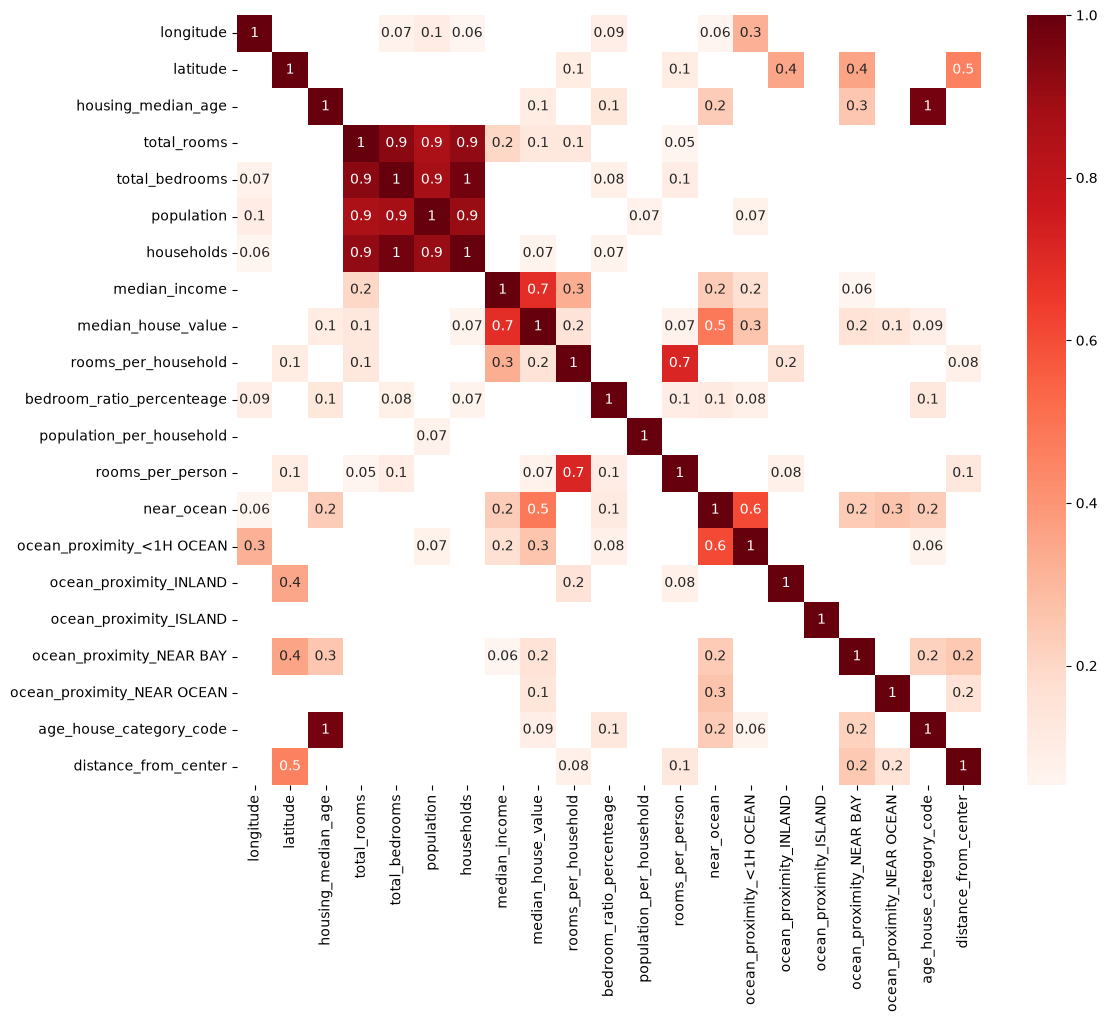

In [70]:
plt.subplots(figsize=(12, 10))
sns.heatmap(df_corr, annot=True, fmt=".1g", cmap='Reds')

In [97]:
X = df.drop(columns=['median_house_value', 'total_bedrooms', 'longitude', 'population', 'ocean_proximity_ISLAND', 'age_house_category', 'location_zone'])

y = df['median_house_value']
X

,latitude,housing_median_age,total_rooms,households,median_income,rooms_per_household,bedroom_ratio_percenteage,population_per_household,rooms_per_person,near_ocean,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,age_house_category_code,distance_from_center
0,37.88,41.0,880.0,126.0,8.3252,6.984127,14.659091,2.555556,0.400621,1,0,0,1,0,4,3.483001
1,37.86,21.0,7099.0,1138.0,8.3014,6.238137,15.579659,2.109842,0.460641,1,0,0,1,0,2,3.462466
2,37.85,52.0,1467.0,177.0,7.2574,8.288136,12.951602,2.802260,0.383065,1,0,0,1,0,4,3.471400
3,37.85,52.0,1274.0,219.0,5.6431,5.817352,18.445840,2.547945,0.421147,1,0,0,1,0,4,3.479098
4,37.85,52.0,1627.0,259.0,3.8462,6.281853,17.209588,2.181467,0.495575,1,0,0,1,0,4,3.479098
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,39.48,25.0,1665.0,330.0,1.5603,5.045455,22.462462,2.560606,0.442604,0,0,1,0,0,2,4.137568
20636,39.49,18.0,697.0,114.0,2.5568,6.114035,21.520803,3.122807,0.421348,0,0,1,0,0,1,4.192350
20637,39.43,17.0,2254.0,433.0,1.7000,5.205543,21.517303,2.325635,0.481629,0,0,1,0,0,1,4.141175
20638,39.43,18.0,1860.0,349.0,1.8672,5.329513,21.989247,2.123209,0.551957,0,0,1,0,0,1,4.182032


In [230]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

In [99]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)


assert X_train.shape[1] == X_test.shape[1]
assert X_train.shape[0] == y_train.shape[0]
assert X_test.shape[0] == y_test.shape[0]

In [100]:
tree = DecisionTreeRegressor(random_state=42)
forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

tree.fit(X_train, y_train)
forest.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [101]:
feature_importances_t = pd.Series(tree.feature_importances_)
feature_importances_f = pd.Series(forest.feature_importances_)
feature_name = pd.Series(X.columns)

pd.concat(
    [pd.Series(feature_name,name='feature_name'),
    pd.Series(feature_importances_f, name='feature_importances_forest'),
    pd.Series(feature_importances_t, name='feature_importances_tree')],
    axis=1
).sort_values(['feature_importances_forest', 'feature_importances_tree'], ascending=False)

,feature_name,feature_importances_forest,feature_importances_tree
4,median_income,0.481189,0.475685
11,ocean_proximity_INLAND,0.130984,0.128405
7,population_per_household,0.100276,0.104779
15,distance_from_center,0.068078,0.075283
0,latitude,0.044994,0.049801
1,housing_median_age,0.041711,0.041242
8,rooms_per_person,0.040388,0.032880
6,bedroom_ratio_percenteage,0.022146,0.023682
5,rooms_per_household,0.020320,0.019174
2,total_rooms,0.017142,0.015671


In [108]:
features_to_drop = [
    'age_house_category_code',
    'ocean_proximity_<1H OCEAN',
    'ocean_proximity_NEAR BAY',
    'ocean_proximity_NEAR OCEAN',
]

X_train_new = X_train.drop(columns=features_to_drop)
X_test_new = X_test.drop(columns=features_to_drop)

# Linear Regression

In [114]:
imputer = KNNImputer(n_neighbors=5)

X_train_new = imputer.fit_transform(X_train_new)
X_test_new = imputer.transform(X_test_new)

In [115]:
mms = MinMaxScaler()
X_train_scaled = mms.fit_transform(X_train_new)
X_test_scaled = mms.transform(X_test_new)

In [223]:
score_linear = cross_val_score(
    LinearRegression(),
    X_train_scaled,
    y_train,
    cv=5,
    scoring='r2'
)
print(score_linear)
print(score_linear.mean())

[0.65817356 0.64099096 0.65336309 0.63786585 0.62266232]
0.6426111564177853


In [122]:
linear = LinearRegression()
linear.fit(X_train_scaled, y_train)
y_pred_linear = linear.predict(X_test_scaled)
y_pred_linear

array([ 87623.4290585 , 122494.08362878, 259514.49413266, ...,
       438579.56975088, 129104.60136804, 201962.7450061 ], shape=(4128,))

In [192]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    # Training set performance
    y_train_pred = model.predict(X_train)
    mse_train = mean_squared_error(y_train, y_train_pred)
    rmse_train = np.sqrt(mse_train)
    r2_train = r2_score(y_train, y_train_pred)

    # Test set performance
    y_test_pred = model.predict(X_test)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_test, y_test_pred)

    print("Training Set Results:")
    print(f"Mean Squared Error: {mse_train}")
    print(f"R-squared: {r2_train}")
    print(f"Root Mean Squared Error: {rmse_train}")
    print("\nTest Set Results:")
    print(f"Mean Squared Error: {mse_test}")
    print(f"R-squared: {r2_test}")
    print(f"Root Mean Squared Error: {rmse_test}")
    return mse_train, rmse_train, r2_train, mse_test, rmse_test, r2_test

# Evaluate the model
mse_train_linear, rmse_train_linear, r2_train_linear, mse_test_linear, rmse_test_linear, r2_test_linear = evaluate_model(linear, X_train_scaled, y_train, X_test_scaled, y_test)

Training Set Results:
Mean Squared Error: 4719053732.245166
R-squared: 0.6469830454576169
Root Mean Squared Error: 68695.36907423357

Test Set Results:
Mean Squared Error: 4964432782.297959
R-squared: 0.621153940126216
Root Mean Squared Error: 70458.73105796016


In [124]:
linear.coef_

array([   20605.94738158,    59437.06275688,    57807.38465128,
          69614.79520599,   656763.68763584, -1431828.43794351,
          63652.85972354,  -243466.35032972,  1354438.80067459,
        -145759.1205343 ,  -214836.88587803,   -57513.21255945])

In [125]:
linear.intercept_

np.float64(173378.11782197736)

# DecisionTree Regressor

In [126]:
tree = DecisionTreeRegressor(max_depth=10, random_state=42, max_leaf_nodes=200)
tree.fit(X_train_scaled, y_train)
y_pred_tree = tree.predict(X_test_scaled)
y_pred_tree

array([ 67898.65671642,  67898.65671642, 471295.19642857, ...,
       491701.83116883,  67898.65671642, 197188.5177453 ], shape=(4128,))

In [225]:
score_tree = cross_val_score(
    tree,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='r2'
)
print(score_tree)
print(score_tree.mean())

[0.72746685 0.70399904 0.71480754 0.73091601 0.72935363]
0.7213086152541313


In [194]:
mse_train_tree, rmse_train_tree, r2_train_tree, mse_test_tree, rmse_test_tree, r2_test_tree = evaluate_model(
    tree, X_train_scaled, y_train, X_test_scaled, y_test
)

Training Set Results:
Mean Squared Error: 2534693174.470111
R-squared: 0.8103879048808598
Root Mean Squared Error: 50345.73640806251

Test Set Results:
Mean Squared Error: 3710837846.950021
R-squared: 0.7168183438477758
Root Mean Squared Error: 60916.64671458879


In [129]:
params = {
    'max_depth': [3, 4, 5, 6, 7, 8, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_leaf_nodes': [20, 50, 100, 200, 300]
}
param_grid = {
    'max_depth': [5, 10, 15, None],
    'max_leaf_nodes': [20, 50, 100, 200]
}

In [130]:
grid = GridSearchCV(
    tree,
    param_grid=params,
    cv=5,                                      # 5-Fold Cross Validation روی Train
    scoring='neg_root_mean_squared_error',     # معیار ارزیابی (برای رگرسیون)
    n_jobs=-1                                  # استفاده از همه‌ی هسته‌های CPU
)

grid.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 4, ...], 'max_leaf_nodes': [20, 50, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time

In [131]:
print("best_estimator :", grid.best_estimator_)
print("best_params :", grid.best_params_)
print("best_score :", grid.best_score_)
print("best_index :", grid.best_index_)


best_estimator : DecisionTreeRegressor(max_leaf_nodes=100, min_samples_leaf=4, random_state=42)
best_params : {'max_depth': None, 'max_leaf_nodes': 100, 'min_samples_leaf': 4, 'min_samples_split': 2}
best_score : -60609.888720151306
best_index : 339


# RandomForest Regressor

In [137]:
forest = RandomForestRegressor(max_depth=10, random_state=42, max_leaf_nodes=200, min_samples_split=10)
forest.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",200
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [138]:
y_pred_forest = forest.predict(X_test_scaled)
y_pred_forest

array([ 64610.31212257,  71275.58387832, 361083.61967041, ...,
       491760.1878085 ,  73642.68376325, 176968.46636178], shape=(4128,))

In [231]:
score_forest = cross_val_score(
    forest,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='r2'
)
print(score_forest)
print(score_forest.mean())

[0.78948417 0.76942397 0.78298367 0.78411772 0.78387098]
0.7819761014660479


In [195]:
mse_train_forest, rmse_train_forest, r2_train_forest, mse_test_forest, rmse_test_forest, r2_test_forest = evaluate_model(
    forest, X_train_scaled, y_train, X_test_scaled, y_test
)

Training Set Results:
Mean Squared Error: 2140197925.346507
R-squared: 0.8398988024736271
Root Mean Squared Error: 46262.27324015225

Test Set Results:
Mean Squared Error: 2996016033.8429704
R-squared: 0.771367864262893
Root Mean Squared Error: 54735.87519938793


# Ridge, Lasso regularization

In [232]:
ridge = Ridge(alpha=1)

ridge.fit(X_train_scaled, y_train)


,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [245]:
score_ridge = cross_val_score(
    ridge, 
    X_train_scaled,
    y_train, 
    cv=5, 
    scoring='r2'
)
print(score_ridge)
print(score_ridge.mean())

[0.64798192 0.63647108 0.64385271 0.64205049 0.63223113]
0.640517467444085


In [234]:
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

grid_ridge = GridSearchCV(
    ridge,
    param_grid,
    cv=5,
    scoring='r2'
)

grid_ridge.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge(alpha=1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter indexes a

In [235]:
print("best_estimator :", grid_ridge.best_estimator_)
print("best_params :", grid_ridge.best_params_)
print("best_score :", grid_ridge.best_score_)
print("best_index :", grid_ridge.best_index_)

best_estimator : Ridge(alpha=0.1)
best_params : {'alpha': 0.1}
best_score : 0.6435324163082171
best_index : 2


In [236]:
mse_train_ridge, rmse_train_ridge, r2_train_ridge, mse_test_ridge, rmse_test_ridge, r2_test_ridge = evaluate_model(
    grid_ridge, X_train_scaled, y_train, X_test_scaled, y_test
)

Training Set Results:
Mean Squared Error: 4721068062.446666
R-squared: 0.6468323600122875
Root Mean Squared Error: 68710.02883456436

Test Set Results:
Mean Squared Error: 4979328735.298741
R-squared: 0.6200171993645054
Root Mean Squared Error: 70564.35881731471


In [237]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

C:\Users\AlmasRayan\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.852e+13, tolerance: 2.207e+10
  model = cd_fast.enet_coordinate_descent(


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [244]:
score_lasso = cross_val_score(
    lasso, 
    X_train_scaled,
    y_train, 
    cv=5, 
    scoring='r2'
)
print(score_lasso)
print(score_lasso.mean())

C:\Users\AlmasRayan\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.095e+13, tolerance: 1.755e+10
  model = cd_fast.enet_coordinate_descent(
C:\Users\AlmasRayan\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.090e+13, tolerance: 1.779e+10
  model = cd_fast.enet_coordinate_descent(
C:\Users\AlmasRayan\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features

[0.6582995  0.6409848  0.65282576 0.63825721 0.62236048]
0.6425455484352641


C:\Users\AlmasRayan\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.017e+13, tolerance: 1.757e+10
  model = cd_fast.enet_coordinate_descent(


In [238]:
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10]
}

grid_lasso = GridSearchCV(
    lasso,
    param_grid,
    cv=5,
    scoring='r2'
)

grid_lasso.fit(X_train_scaled, y_train)

C:\Users\AlmasRayan\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.127e+13, tolerance: 1.755e+10
  model = cd_fast.enet_coordinate_descent(
C:\Users\AlmasRayan\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.128e+13, tolerance: 1.779e+10
  model = cd_fast.enet_coordinate_descent(
C:\Users\AlmasRayan\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Lasso(alpha=0.1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter indexes

In [239]:
print("best_estimator :", grid_ridge.best_estimator_)
print("best_params :", grid_ridge.best_params_)
print("best_score :", grid_ridge.best_score_)
print("best_index :", grid_ridge.best_index_)

best_estimator : Ridge(alpha=0.1)
best_params : {'alpha': 0.1}
best_score : 0.6435324163082171
best_index : 2


In [240]:
mse_train_lasso, rmse_train_lasso, r2_train_lasso, mse_test_lasso, rmse_test_lasso, r2_test_lasso = evaluate_model(
    grid_lasso, X_train_scaled, y_train, X_test_scaled, y_test
)

Training Set Results:
Mean Squared Error: 4726312476.470015
R-squared: 0.6464400425749522
Root Mean Squared Error: 68748.18162300742

Test Set Results:
Mean Squared Error: 4988708603.011655
R-squared: 0.619301402398164
Root Mean Squared Error: 70630.79075737193


# GradientBoosting Regressor

In [162]:
graidient_boost = GradientBoostingRegressor(n_estimators=100, random_state=42, learning_rate=0.1, max_depth=3)

graidient_boost.fit(X_train_scaled, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [163]:
y_pred_gb = graidient_boost.predict(X_test_scaled)

In [247]:
score_gb = cross_val_score(
    graidient_boost,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='r2'
)
print(score_gb)
print(score_gb.mean())

[0.79400032 0.77635621 0.79071284 0.79093897 0.77984085]
0.786369838003803


> ⚠️ **Note:** Gradient Boosting was not fully tuned due to hardware limitations.
> `GridSearchCV` ran for approximately **30 minutes** before the system became unresponsive, so the experiment was stopped.
>
> **The limitation was computational, not model performance.**


In [ ]:
# param_grid = {
#     'n_estimators': [100, 200],
#     'learning_rate': [0.05, 0.1],
#     'max_depth': [2, 3, 4]
# }

# grid_boost = GridSearchCV(
#     param_grid=params,
#     estimator=graidient_boost,
#     cv=5,
#     scoring='r2',
#     n_jobs=-2
# )
# grid_boost.fit(X_train_scaled, y_train)


# print("best_estimator :", grid_boost.best_estimator_)
# print("best_params :", grid_boost.best_params_)
# print("best_score :", grid_boost.best_score_)
# print("best_index :", grid_boost.best_index_)

In [199]:
mse_train_gb, rmse_train_gb, r2_train_gb, mse_test_gb, rmse_test_gb, r2_test_gb = evaluate_model(
    graidient_boost, X_train_scaled, y_train, X_test_scaled, y_test
)

Training Set Results:
Mean Squared Error: 2590746195.5022593
R-squared: 0.8061947619542471
Root Mean Squared Error: 50899.373232901984

Test Set Results:
Mean Squared Error: 2963656698.44386
R-squared: 0.7738372715957511
Root Mean Squared Error: 54439.47738951817


# HistGradientBoosting Regressor

In [291]:
hgboost = HistGradientBoostingRegressor(random_state=42)

hgboost.fit(X_train_scaled, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'squared_error'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide ` and:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_categorical.py`... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 

In [248]:
score_hgb = cross_val_score(
    hgboost,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='r2'
)
print(score_hgb)
print(score_hgb.mean())

[0.8362668  0.81636516 0.82501994 0.82935878 0.82142709]
0.8256875520455959


In [200]:
mse_train_hgb, rmse_train_hgb, r2_train_hgb, mse_test_hgb, rmse_test_hgb, r2_test_hgb = evaluate_model(
    hgboost, X_train_scaled, y_train, X_test_scaled, y_test
)

Training Set Results:
Mean Squared Error: 1671674448.6432643
R-squared: 0.8749475093250105
Root Mean Squared Error: 40886.115597391545

Test Set Results:
Mean Squared Error: 2344828870.580622
R-squared: 0.8210612938772495
Root Mean Squared Error: 48423.433073054846


In [189]:
param_grid_hgbr = {
    'max_iter': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_leaf_nodes': [15, 31, 63],
    'l2_regularization': [0, 1]
}

grid_hgboost = GridSearchCV(
    param_grid=param_grid_hgbr,
    estimator=hgboost,
    cv=3,
    scoring='r2',
    n_jobs=2
)
grid_hgboost.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",HistGradientB...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'l2_regularization': [0, 1], 'learning_rate': [0.05, 0.1], 'max_iter': [100, 200], 'max_leaf_nodes': [15, 31, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candida

In [190]:
print("best_estimator :", grid_hgboost.best_estimator_)
print("best_params :", grid_hgboost.best_params_)
print("best_score :", grid_hgboost.best_score_)
print("best_index :", grid_hgboost.best_index_)

best_estimator : HistGradientBoostingRegressor(l2_regularization=1, learning_rate=0.05,
                              max_iter=200, max_leaf_nodes=63, random_state=42)
best_params : {'l2_regularization': 1, 'learning_rate': 0.05, 'max_iter': 200, 'max_leaf_nodes': 63}
best_score : 0.8297052651313331
best_index : 17


In [295]:
y_pred_hgb = hgboost.predict(X_test_scaled)

------------------------

In [221]:
mse_train = [mse_train_linear, mse_train_tree, mse_train_forest, mse_train_ridge, mse_train_lasso, mse_train_gb, mse_train_hgb]
rmse_train = [rmse_train_linear, rmse_train_tree, rmse_train_forest, rmse_train_ridge, rmse_train_lasso, rmse_train_gb, rmse_train_hgb]
r2_train = [r2_train_linear, r2_train_tree, r2_train_forest, r2_train_ridge, r2_train_lasso, r2_train_gb, r2_train_hgb]
mse_test = [mse_test_linear, mse_test_tree, mse_test_forest, mse_test_ridge, mse_test_lasso, mse_test_gb, mse_test_hgb]
rmse_test = [rmse_test_linear, rmse_test_tree, rmse_test_forest, rmse_test_ridge, rmse_test_lasso, rmse_test_gb, rmse_test_hgb]
r2_test = [r2_test_linear, r2_test_tree, r2_test_forest, r2_test_ridge, r2_test_lasso, r2_test_gb, r2_test_hgb]


In [222]:
models = [
    'Linear',
    'Tree',
    'Forest',
    'Ridge',
    'Lasso',
    'GradientBoosting',
    'HistGradientBoosting'
]

results = pd.DataFrame({
    'model': models,
    'mse_train': mse_train,
    'rmse_train': rmse_train,
    'r2_train': r2_train,
    'mse_test': mse_test,
    'rmse_test': rmse_test,
    'r2_test': r2_test
})
results.sort_values(['r2_test', 'r2_train'], ascending=False)

,model,mse_train,rmse_train,r2_train,mse_test,rmse_test,r2_test
6,HistGradientBoosting,1.671674e+09,40886.115597,0.874948,2.344829e+09,48423.433073,0.821061
4,Lasso,2.590746e+09,50899.373233,0.806195,2.963657e+09,54439.477390,0.773837
5,GradientBoosting,2.590746e+09,50899.373233,0.806195,2.963657e+09,54439.477390,0.773837
2,Forest,2.140198e+09,46262.273240,0.839899,2.996016e+09,54735.875199,0.771368
1,Tree,2.534693e+09,50345.736408,0.810388,3.710838e+09,60916.646715,0.716818
0,Linear,4.719054e+09,68695.369074,0.646983,4.964433e+09,70458.731058,0.621154
3,Ridge,4.721068e+09,68710.028835,0.646832,4.979329e+09,70564.358817,0.620017


In [252]:
cv_results = pd.DataFrame({
    'Linear': score_linear,
    'Tree': score_tree,
    'Forest': score_forest,
    'Ridge': score_ridge,
    'Lasso': score_lasso,
    'GradientBoosting': score_gb,
    'HistGradientBoosting': score_hgb
})

cv_results

,Linear,Tree,Forest,Ridge,Lasso,GradientBoosting,HistGradientBoosting
0,0.658174,0.727467,0.789484,0.647982,0.658299,0.794000,0.836267
1,0.640991,0.703999,0.769424,0.636471,0.640985,0.776356,0.816365
2,0.653363,0.714808,0.782984,0.643853,0.652826,0.790713,0.825020
3,0.637866,0.730916,0.784118,0.642050,0.638257,0.790939,0.829359
4,0.622662,0.729354,0.783871,0.632231,0.622360,0.779841,0.821427


# plot best Model

In [286]:
results_sorted1 = results.sort_values(['r2_test'], ascending=False)
results_sorted2 = results.sort_values(['r2_train'], ascending=False)

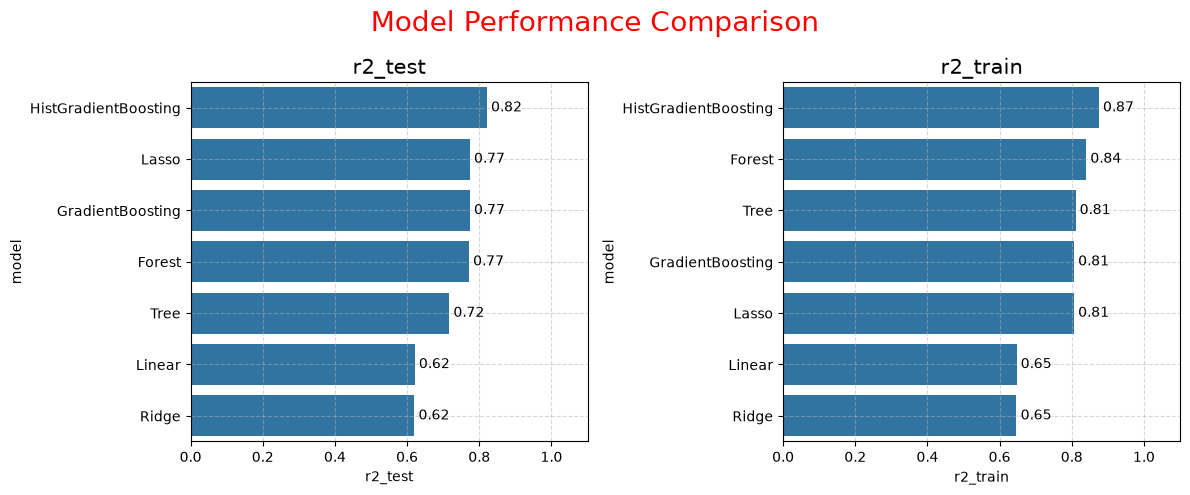

In [289]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(results_sorted1, y='model', x='r2_test', ax=axs[0])
axs[0].set_title('r2_test', size=15)

sns.barplot(results_sorted2, y='model', x='r2_train', ax=axs[1])
axs[1].set_title('r2_train', size=15)

for container in axs[0].containers:
    axs[0].bar_label(container, fmt='%.2f', padding=3)
    
for container in axs[1].containers:
    axs[1].bar_label(container, fmt='%.2f', padding=3)

fig.suptitle('Model Performance Comparison', size=20, color='red')

axs[0].set_xlim(0, 1.1)
axs[1].set_xlim(0, 1.1)
plt.tight_layout()
for ax in axs:
    ax.grid(alpha=0.5, linestyle='--')

----------------------------------------------------------------------------

# Error Analysis

In [301]:
residual = y_test - y_pred_hgb
residual

20046    -8695.193648
3024    -32324.946911
15663    53381.317536
20484   -30735.329965
9814     58024.454836
             ...     
15362    18975.056982
16623    41881.156433
18086    -2835.327007
2144     -1854.892714
3665    -21368.771345
Name: median_house_value, Length: 4128, dtype: float64

((array([-3.58599225, -3.34761805, -3.21608001, ...,  3.21608001,
          3.34761805,  3.58599225], shape=(4128,)),
  array([-261298.32789685, -231947.5642901 , -192659.47661981, ...,
          306077.57220175,  311820.22265415,  366113.93685243],
        shape=(4128,))),
 (np.float64(45928.75362476234),
  np.float64(-158.08693885316518),
  np.float64(0.9477358799367717)))

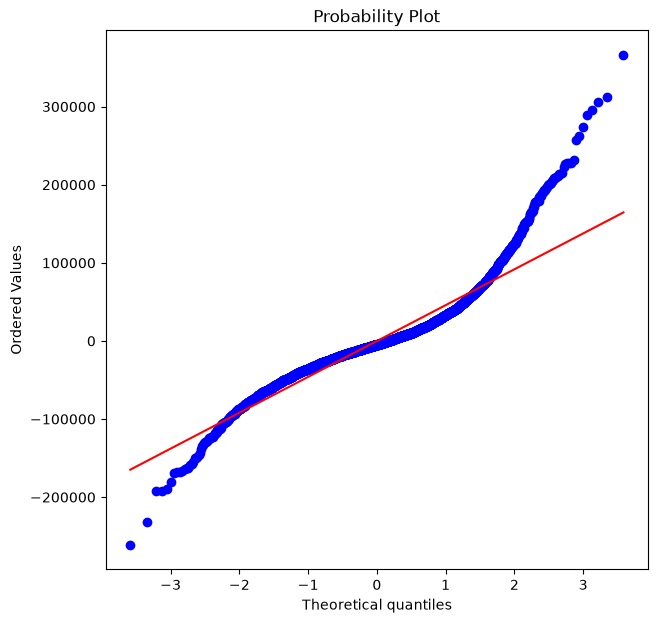

In [300]:
import scipy.stats as stats

plt.figure(figsize=(7, 7))

stats.probplot(residual, dist='norm', plot=plt)

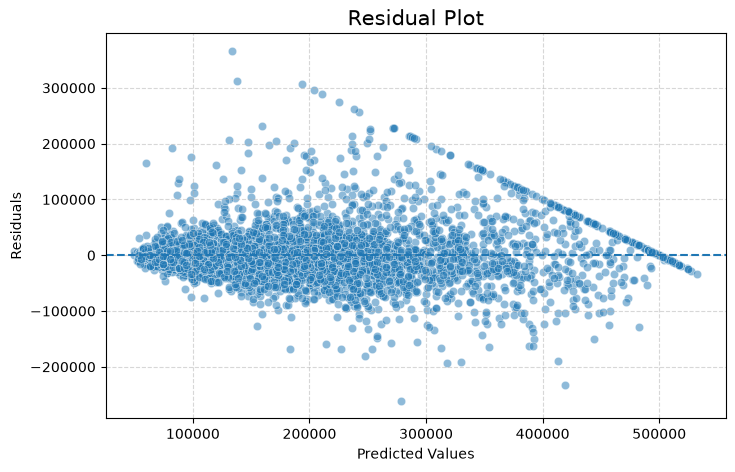

In [303]:
plt.figure(figsize=(8, 5))

sns.scatterplot(x=y_pred_hgb, y=residual, alpha=0.5)

plt.axhline(0, linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot', size=15)

plt.grid(alpha=0.5, linestyle='--')
plt.show()

----------------------------------

# Save Best Model


In [304]:
import joblib

joblib.dump(hgboost, 'hist_gradient_boosting.pkl')

['hist_gradient_boosting.pkl']